In [26]:
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report
import numpy as np
import matplotlib.pyplot as plt

In [35]:
df=pd.read_csv('diabetes.csv')
numerical_cols=['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age']


In [36]:
# Handle missing values for numerical columns

numerical_data=df[numerical_cols]
imputer_num=SimpleImputer(strategy='mean')
numerical_data = imputer_num.fit_transform(numerical_data)
numerical_df = pd.DataFrame(numerical_data, columns=numerical_cols)
numerical_df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6.0,148.0,72.0,35.0,0.0,33.6,0.627,50.0
1,1.0,85.0,66.0,29.0,0.0,26.6,0.351,31.0
2,8.0,183.0,64.0,0.0,0.0,23.3,0.672,32.0
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0
4,0.0,137.0,40.0,35.0,168.0,43.1,2.288,33.0
...,...,...,...,...,...,...,...,...
763,10.0,101.0,76.0,48.0,180.0,32.9,0.171,63.0
764,2.0,122.0,70.0,27.0,0.0,36.8,0.340,27.0
765,5.0,121.0,72.0,23.0,112.0,26.2,0.245,30.0
766,1.0,126.0,60.0,0.0,0.0,30.1,0.349,47.0


In [37]:
# Standardize the data

scaler=StandardScaler()
data_Scaled = scaler.fit_transform(numerical_df)
data_Scaled

array([[ 0.63994726,  0.84832379,  0.14964075, ...,  0.20401277,
         0.46849198,  1.4259954 ],
       [-0.84488505, -1.12339636, -0.16054575, ..., -0.68442195,
        -0.36506078, -0.19067191],
       [ 1.23388019,  1.94372388, -0.26394125, ..., -1.10325546,
         0.60439732, -0.10558415],
       ...,
       [ 0.3429808 ,  0.00330087,  0.14964075, ..., -0.73518964,
        -0.68519336, -0.27575966],
       [-0.84488505,  0.1597866 , -0.47073225, ..., -0.24020459,
        -0.37110101,  1.17073215],
       [-0.84488505, -0.8730192 ,  0.04624525, ..., -0.20212881,
        -0.47378505, -0.87137393]], shape=(768, 8))

In [38]:
# Apply PCA

pca=PCA() # Keep all components
X_pca = pca.fit_transform(data_Scaled)
X_pca

array([[ 1.06850273,  1.23489499, -0.09592984, ...,  0.35718251,
         0.85882133,  0.97430355],
       [-1.12168331, -0.73385167,  0.71293816, ..., -0.40632934,
         0.75703403,  0.35421454],
       [-0.39647671,  1.59587594, -1.76067844, ..., -0.04001752,
        -1.15299029,  1.06852795],
       ...,
       [-0.28347525,  0.09706503,  0.07719194, ..., -0.53826993,
        -0.33556321,  0.2894389 ],
       [-1.06032431,  0.83706234, -0.42503045, ...,  0.15330712,
         1.18030813, -0.53434386],
       [-0.83989172, -1.15175485,  1.00917817, ..., -0.15009639,
         0.24523536,  0.51594622]], shape=(768, 8))

In [39]:
# Variance captured by each component

explained_variance=pca.explained_variance_ratio_
cumulative_variance=np.cumsum(explained_variance)
cumulative_variance

array([0.26179749, 0.47819876, 0.60690249, 0.71634362, 0.81163667,
       0.89696522, 0.94944224, 1.        ])

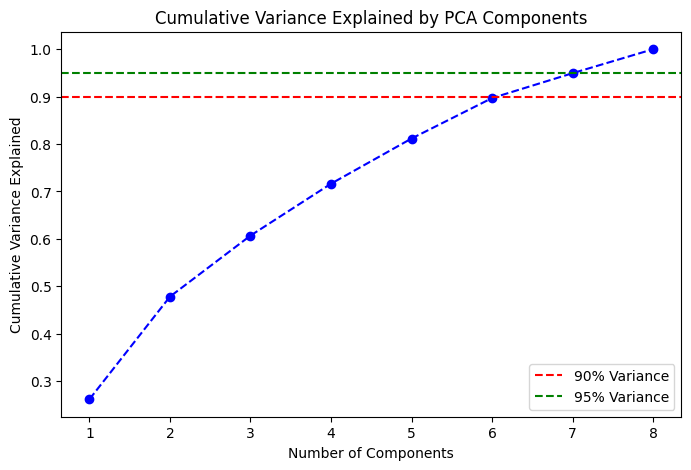

In [33]:
# Plot Cumulative Variance

plt.figure(figsize=(8,5))
plt.plot(range(1,len(cumulative_variance) + 1), cumulative_variance, marker='o',linestyle='--', color='b')
plt.title('Cumulative Variance Explained by PCA Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance Explained')
plt.axhline(y=0.9, color='r',linestyle='--', label='90% Variance')
plt.axhline(y=0.95, color='g',linestyle='--', label='95% Variance')
plt.legend()
plt.show()

In [40]:
#Display PCA results
print("Explained Variance Ratio(For each PC):")
print(explained_variance)
print("\nCumulative Variance :")
print(cumulative_variance)


# Show composition (loadings) of each Principal Component 
loadings = pd.DataFrame (pca.components_,columns=numerical_cols, index=[f'PC{i+1}' for i in range(len(numerical_cols))])
print("\nComposition (loadings) of each Principal Component : ")
print(loadings)

Explained Variance Ratio(For each PC):
[0.26179749 0.21640127 0.12870373 0.10944113 0.09529305 0.08532855
 0.05247702 0.05055776]

Cumulative Variance :
[0.26179749 0.47819876 0.60690249 0.71634362 0.81163667 0.89696522
 0.94944224 1.        ]

Composition (loadings) of each Principal Component : 
     Pregnancies   Glucose  BloodPressure  SkinThickness   Insulin       BMI  \
PC1     0.128432  0.393083       0.360003       0.439824  0.435026  0.451941   
PC2     0.593786  0.174029       0.183892      -0.331965 -0.250781 -0.100960   
PC3     0.013087 -0.467923       0.535494       0.237674 -0.336709  0.361865   
PC4     0.080691 -0.404329       0.055986       0.037976 -0.349944  0.053646   
PC5     0.475606 -0.466328      -0.327953       0.487862  0.346935 -0.253204   
PC6     0.193598  0.094162      -0.634116       0.009589 -0.270651  0.685372   
PC7    -0.588790 -0.060153      -0.192118       0.282213 -0.132010 -0.035366   
PC8     0.117841  0.450355      -0.011296       0.566284 -0.5

# Select first three principal components

X_selected=X_pca[:,:3]

# Prepare the target variable
y=df['Outcome']

#Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

# Train a Logistic Regression Model
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_test)

accuracy = accuracy_score(y_test,y_pred)
conf_matrix = confusion_matrix(y_test,y_pred)
report = classification_report(y_test,y_pred)
print(f"Accuracy: {accuracy:.2f}")
print(conf_matrix)
print(report)